## Assignment C

This assignment highlights some of the challenges you will encounter with real-world data analysis. The data you will be working with is artificially generated containing several inconsistencies. The goal is to identify these inconsistencies and take steps accordingly to correct and combine the data. The description is intentionally incomplete  where you can put your knowledge, creativity and skills to work.

### Data

Several labs across the globe have measured gene expression of groups of individuals specifically selected for the study.    The gene expression data is already collected and merged together, however the  anthropometric data from different labs are delivered separately. In order to do the analysis all data have to be combined in a single file containing all information.

### The analysis

Once the data is combined you will be able to carry out the analysis:

1. Study the distribution of Body Mass Index (BMI) in different populations.
2. Determine if BMI is related to the expression of certain genes.


### Deliverables

1. A single properly merged dataset containing all information.
2. A report (.ipynb) with two sections, i) data preprocessing, ii) data analysis.

In the data preprocessing part, please enumerate en briefly describe the inconsistencies you've resolved in the data.

### Organization of Files/Directories

Please create two separate subdirectories for the data:

- `assignment_c/data` :  the raw data files that is provided with this assignment (separate zip file: assignment_C_data.zip )
- `assignment_c/out` :  intermediate and final dataset(s) created by you

This way you can make sure that you'll not modify the original dataset in `assignment_c/data` and that files generated into `assignment_c/out` can safely be discarded whenever a re-analysis is needed.

The directory structure for your github repository should look something like this :

```
.
assignment_C
├── assignment_C.ipynb
├── data
│   ├── NL.csv
│   ├── PL.csv
│   ├── UK.csv
│   ├── US.csv
│   └── genes.csv
└── out
    └── combined_dataset.csv
```




SOLUTION START

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### (i) Data inspection and data cleaning

In [2]:
# Load the datasets 
NL = pd.read_csv('data/NL.csv')
PL = pd.read_csv('data/PL.csv')
UK = pd.read_csv('data/UK.csv')
US = pd.read_csv('data/US.csv')

In [3]:
# Inspect the datasets
print(NL.head())
print(PL.head())    
print(UK.head())
print(US.head())

        id  weight  height     sex smokes
0  NL_0001     105     188    male    yes
1  NL_0002     114     177    male    yes
2  NL_0003      70     176  female     no
3  NL_0004      68     175    male     no
4  NL_0005      86     186    male    yes
      id  heigth  weight     sex smokes
0  S0001   178.0    77.0  female  False
1  S0002   155.0    74.0    male  False
2  S0003   173.0    70.0    male   True
3  S0004   167.0    95.0    male  False
4  S0005   181.0    78.0  female  False
        id  weight  height     sex  smokes
0  UK_0001   180.8    -1.0    male       0
1  UK_0002   141.1    65.7    male       0
2  UK_0003   180.8    68.5    male       0
3  UK_0004   218.3    68.9    male       0
4  UK_0005   147.7    62.6  female       0
      id  weight  height     sex smokes
0  S1272      61     NaN  female     no
1  S1288     105     NaN  female     no
2  S1361      92     NaN  female     no
3  S1091      78   182.0    male     no
4  S1351      83     NaN  female     no


In [4]:
# Check data types and column names
print(NL.dtypes)
print(PL.dtypes)
print(UK.dtypes)
print(US.dtypes)

id        object
weight     int64
height     int64
sex       object
smokes    object
dtype: object
id         object
heigth    float64
weight    float64
sex        object
smokes     object
dtype: object
id         object
weight    float64
height    float64
sex        object
smokes      int64
dtype: object
id         object
weight      int64
height    float64
sex        object
smokes     object
dtype: object


In [5]:
# Fix column name 
PL.rename(columns={'heigth':'height'}, inplace=True)
PL.head(2)

,id,height,weight,sex,smokes
0,S0001,178.0,77.0,female,False
1,S0002,155.0,74.0,male,False


In [6]:
# Fix column order to match the other datasets
PL = PL[["id", "weight", "height", "sex", "smokes"]]
PL.head(2)

,id,weight,height,sex,smokes
0,S0001,77.0,178.0,female,False
1,S0002,74.0,155.0,male,False


In [7]:
# Check ranges of `height` in all datasets
print('NL:', NL['height'].describe())
print('PL:', PL['height'].describe())

NL: count    1322.000000
mean      177.176248
std         9.276962
min       153.000000
25%       170.000000
50%       176.500000
75%       184.000000
max       207.000000
Name: height, dtype: float64
PL: count    1472.000000
mean      169.404891
std         9.580837
min       146.000000
25%       161.000000
50%       168.000000
75%       176.000000
max       202.000000
Name: height, dtype: float64


In [8]:
print('UK:', UK['height'].describe())
print('US:', US['height'].describe())

UK: count    694.000000
mean      64.406484
std       14.566331
min       -1.000000
25%       64.600000
50%       67.300000
75%       69.700000
max       78.000000
Name: height, dtype: float64
US: count    226.000000
mean     174.566372
std        6.892026
min      157.000000
25%      170.000000
50%      174.000000
75%      179.000000
max      198.000000
Name: height, dtype: float64


In [9]:
# Fix negative values in `height`
UK.loc[UK['height'] <= 0, 'height'] = pd.NA

In [10]:
# Recheck
print('UK:', UK['height'].describe())

UK: count    663.000000
mean      67.464706
std        3.523819
min       58.300000
25%       65.000000
50%       67.700000
75%       70.100000
max       78.000000
Name: height, dtype: float64


In [11]:
# Check summaries for `weight` in all datasets
print('NL:', NL['weight'].describe())
print('PL:', PL['weight'].describe())

NL: count    1322.000000
mean       80.231467
std        16.460242
min        35.000000
25%        69.000000
50%        79.500000
75%        91.750000
max       142.000000
Name: weight, dtype: float64
PL: count    1494.000000
mean       75.417001
std        16.261988
min        35.000000
25%        65.000000
50%        72.000000
75%        86.000000
max       149.000000
Name: weight, dtype: float64


In [12]:
print('UK:', UK['weight'].describe())
print('US:', US['weight'].describe())

UK: count    694.000000
mean     273.200865
std      264.109384
min       61.700000
25%      158.700000
50%      185.200000
75%      211.600000
max      999.000000
Name: weight, dtype: float64
US: count    461.000000
mean      81.754881
std       16.541733
min       40.000000
25%       70.000000
50%       81.000000
75%       93.000000
max      138.000000
Name: weight, dtype: float64


In [13]:
# Standardize notation for missing values to `NA` for all datasets
UK['weight'] = UK['weight'].replace({999: pd.NA})
UK['weight'] = pd.to_numeric(UK['weight'], errors='coerce')

In [14]:
# Recheck
UK['weight'].describe()

count    614.000000
mean     178.634202
std       33.929618
min       61.700000
25%      156.500000
50%      180.800000
75%      200.600000
max      284.400000
Name: weight, dtype: float64

In [15]:
# Standardize `weight` and `height` to be on the same scale across all datasets
UK['weight'] = UK['weight'] * 0.453592      # pounds to kg
UK['height'] = UK['height'] * 2.54          # inches to cm
UK['height'] = UK['height'].round(0)
UK.head(5)

,id,weight,height,sex,smokes
0,UK_0001,82.009434,NaN,male,0
1,UK_0002,64.001831,167.0,male,0
2,UK_0003,82.009434,174.0,male,0
3,UK_0004,99.019134,175.0,male,0
4,UK_0005,66.995538,159.0,female,0


In [16]:
# Check possible values in the `sex` column
print("NL:", NL['sex'].unique())
print("PL:", PL['sex'].unique())
print("UK:", UK['sex'].unique())
print("US:", US['sex'].unique())

NL: ['male' 'female']
PL: ['female' 'male' nan]
UK: ['male' 'female' 'FEMALE' 'Woman' 'Male' 'MALE' 'Female']
US: ['female' 'male']


In [17]:
# Fix inconsistent notations in the `sex` column	
UK['sex'] = UK['sex'].str.lower()
UK['sex'] = UK['sex'].replace( {'woman':'female'})

In [18]:
# Recheck
print("UK:", UK['sex'].unique())

UK: ['male' 'female']


In [20]:
# Check possible values in the `smokes` column
print("NL:", NL['smokes'].unique())
print("PL:", PL['smokes'].unique())
print("UK:", UK['smokes'].unique())
print("US:", US['smokes'].unique())

NL: ['yes' 'no']
PL: [False True nan]
UK: [0 1]
US: ['no' 'yes']


In [21]:
# Standardize smoking values across datasets
PL['smokes'] = PL['smokes'].replace({True: 'yes', False: 'no'}) 
UK['smokes'] = UK['smokes'].replace({0:'no',1:'yes'})

In [22]:
# Recheck
print("PL:", PL['smokes'].unique())
print("UK:", UK['smokes'].unique())

PL: ['no' 'yes' nan]
UK: ['no' 'yes']


In [23]:
# Check for missing values
print('NL:', NL.isna().sum())
print('PL:', PL.isna().sum())
print('UK:', UK.isna().sum())
print('US:', US.isna().sum())

NL: id        0
weight    0
height    0
sex       0
smokes    0
dtype: int64
PL: id          0
weight     44
height     66
sex        34
smokes    104
dtype: int64
UK: id         0
weight    80
height    31
sex        0
smokes     0
dtype: int64
US: id          0
weight      0
height    235
sex         0
smokes      0
dtype: int64


In [24]:
# Multiply by 100 to get percentage of missing values
print('PL:', PL.isna().mean()*100)
print('UK:', UK.isna().mean()*100)
print('US:', US.isna().mean()*100)

PL: id        0.000000
weight    2.860858
height    4.291287
sex       2.210663
smokes    6.762029
dtype: float64
UK: id         0.000000
weight    11.527378
height     4.466859
sex        0.000000
smokes     0.000000
dtype: float64
US: id         0.000000
weight     0.000000
height    50.976139
sex        0.000000
smokes     0.000000
dtype: float64


Missing values are present in all datasets except `NL`. `PL` dataset contains 44 missing values for weight (2.86%), 66 for height (4.29%), 34 for sex (2.21%), and 104 for the smokes variable (6.76%). `UK` dataset shows 80 missing entries for weight (11.53%) and 31 for height (4.47%), while all entries for sex and smokes are complete. `US` dataset contains no missing values for weight, sex, or smokes, but has 235 missing entries for height(50.98%). These missing values were neither discarded nor imputed during the analysis.

In [25]:
# Merge datasets
df = pd.concat( [NL, PL, UK, US], ignore_index=True)
df.head(), df.tail()

(        id  weight  height     sex smokes
 0  NL_0001   105.0   188.0    male    yes
 1  NL_0002   114.0   177.0    male    yes
 2  NL_0003    70.0   176.0  female     no
 3  NL_0004    68.0   175.0    male     no
 4  NL_0005    86.0   186.0    male    yes,
          id  weight  height     sex smokes
 4010  S1300    61.0     NaN  female     no
 4011  S1169   112.0   179.0    male     no
 4012  S1048    96.0   172.0    male    yes
 4013  S1352    62.0     NaN  female     no
 4014  S1207    70.0   169.0    male     no)

In [26]:
# Check for duplicates in the merged dataset
df['id'].duplicated().sum()

np.int64(199)

In [27]:
duplicates = df['id'].duplicated()
print(df[duplicates])

         id  weight  height   sex smokes
2105  S030f    65.0   161.0  male     no
2106  S030f    65.0   161.0  male     no
2107  S030f    65.0   161.0  male     no
2108  S030f    65.0   161.0  male     no
2109  S030f    65.0   161.0  male     no
...     ...     ...     ...   ...    ...
2299  S030f    65.0   161.0  male     no
2300  S030f    65.0   161.0  male     no
2301  S030f    65.0   161.0  male     no
2302  S030f    65.0   161.0  male     no
2303  S030f    65.0   161.0  male     no

[199 rows x 5 columns]


It looks like al 199 dupliates are the exact copies of the same individual. I will keep only the first one and discard the rest.

In [28]:
df = df.drop_duplicates(subset='id', keep='first')

In [29]:
#  Recheck for duplicates
print(df['id'].duplicated().sum())  

0


In [30]:
# Save cleaned datasets
NL_clean = NL.copy()
NL_clean.to_csv('out/NL_clean.csv', index=False)

PL_clean = PL.copy()
PL_clean.to_csv('out/PL_clean.csv', index=False)

UK_clean = UK.copy()
UK_clean.to_csv('out/UK_clean.csv', index=False)

US_clean = US.copy()
US_clean.to_csv('out/US_clean.csv', index=False)

# Save merged dataset
merged_df_clean = df.copy()
merged_df_clean.to_csv('out/merged_df_clean.csv', index=False)

In [31]:
# Load the `genes` dataset
genes = pd.read_csv('data/genes.csv')
print(genes.head())

        id source     geneA      geneB       geneC
0  NL_0590     NL  0.725787  10.516221   88.803319
1  NL_0395     NL  1.827190  -1.364823  100.720557
2  NL_0183     NL  2.701437  14.623456   89.894749
3  NL_0308     NL  1.729680  10.100416   99.305338
4  NL_0826     NL  0.470720  -3.894969  103.650732


In [32]:
# Check data types and column names
print(genes.dtypes)

id         object
source     object
geneA     float64
geneB     float64
geneC     float64
dtype: object


In [33]:
# Check for missing values
print(genes.isna().sum())

id        0
source    0
geneA     0
geneB     0
geneC     0
dtype: int64


In [34]:
# Check for duplicates
print(genes['id'].duplicated().sum())

0


In [35]:
# Compute BMI

merged_df = merged_df_clean.copy()

# Convert height from cm to m
merged_df['height_m'] = merged_df['height'] / 100

# Compute BMI
merged_df['BMI'] = merged_df['weight'] / (merged_df['height_m'] ** 2)
merged_df['BMI'] = merged_df['BMI'].round(2)

# Check 
merged_df.head(5)

,id,weight,height,sex,smokes,height_m,BMI
0,NL_0001,105.0,188.0,male,yes,1.88,29.71
1,NL_0002,114.0,177.0,male,yes,1.77,36.39
2,NL_0003,70.0,176.0,female,no,1.76,22.60
3,NL_0004,68.0,175.0,male,no,1.75,22.20
4,NL_0005,86.0,186.0,male,yes,1.86,24.86


In [36]:
# Merge the two data sets
merged_df_genes = pd.merge(merged_df, genes, on='id')
print(merged_df_genes.head())

        id  weight  height     sex smokes  height_m    BMI source      geneA  \
0  NL_0001   105.0   188.0    male    yes      1.88  29.71     NL   2.852573   
1  NL_0002   114.0   177.0    male    yes      1.77  36.39     NL  23.406720   
2  NL_0003    70.0   176.0  female     no      1.76  22.60     NL   0.375769   
3  NL_0004    68.0   175.0    male     no      1.75  22.20     NL   0.800761   
4  NL_0005    86.0   186.0    male    yes      1.86  24.86     NL   1.008053   

       geneB       geneC  
0  15.139682   88.698757  
1  23.477106  105.267242  
2  -6.081572   99.667734  
3 -10.197789   82.935411  
4   2.101691   97.957148  


In [37]:
# Save the merged dataset with genes
merged_df_genes.to_csv('out/merged_df_genes.csv', index=False)  

### (ii) The analysis 

#### 1. Distribution of BMI in different populations

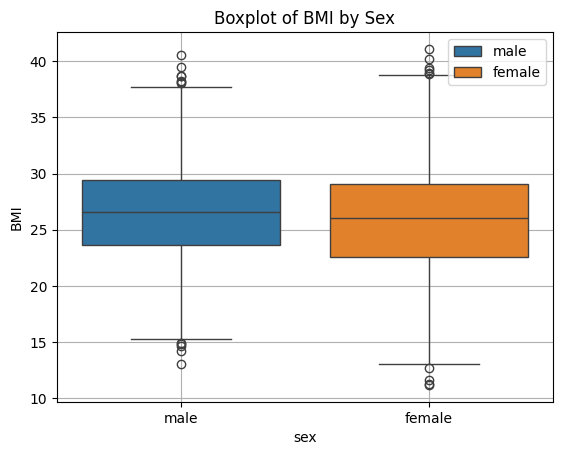

In [38]:
# Boxplot of BMI by sex
sns.boxplot(data=merged_df, y= 'BMI', x='sex', hue='sex')
plt.legend(loc='upper right')

plt.title('Boxplot of BMI by Sex')
plt.ylabel('BMI')
plt.grid(True)

**Interpretation**

The boxplot illustrates the distribution of BMI by sex. Overall, the two groups show similar patterns, with BMI values ranging roughly between 15 and 40. Most individuals, regardless of sex, fall in the categories of "normal weight" (18.5 - 24.9, Furey, n.d.) and "overweight" (25.0 - 29.9, Furey, n.d.).

Looking at group-level differences, males tend to have a slightly higher median BMI compared to females. The spread of BMI values is somewhat wider among females, suggesting greater variability within this group. Outliers are present in both groups, with a few extreme values at both ends of the distribution.

This visualization is based only on complete cases — individuals with non-missing values for both BMI and sex — since any records with missing data were automatically excluded from the plot.

This visualization is based only on complete cases — individuals with non-missing values for both BMI and sex — since any records with missing data were automatically excluded from the plot.

---
Reference: 
<br>
Furey, E. (n.d.). BMI calculator: Body mass index. CalculatorSoup. 
<br>
https://www.calculatorsoup.com/calculators/health/bmi-calculator.php

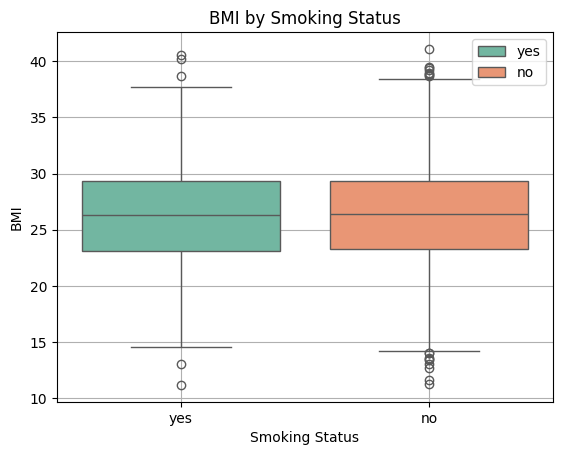

In [39]:
# Boxplot of BMI by smoking status
sns.boxplot(data=merged_df, y='BMI', x='smokes', hue='smokes', palette = 'Set2')
plt.legend(loc='upper right')
plt.title('BMI by Smoking Status')
plt.ylabel('BMI')
plt.xlabel('Smoking Status')
plt.grid(True)

**Interpretation**

The boxplot compares the distribution of BMI between individuals who smoke and those who do not. Overall, the BMI distributions appear quite similar across the two groups. Both groups have a median BMI around 26–27, and most individuals fall within the "normal weight" and "overweight" ranges (Furey, n.d.).

At a group level, smokers display slightly more variability in BMI, as suggested by a wider interquartile range, and both groups contain a number of outliers at both the lower and upper ends of the distribution. 

This visualization is based only on complete cases — individuals with non-missing values for both BMI and smoking status — since any records with missing data were automatically excluded from the plot.

---
Reference: 
<br>
Furey, E. (n.d.). BMI calculator: Body mass index. CalculatorSoup. 
<br>
https://www.calculatorsoup.com/calculators/health/bmi-calculator.php

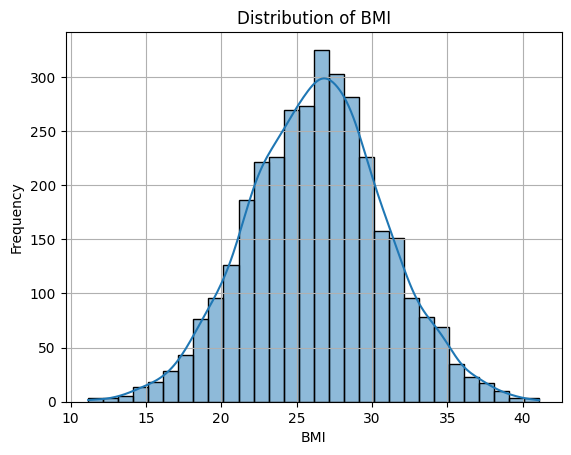

In [40]:
# Histogram of BMI distribution
sns.histplot(data=merged_df, x='BMI', bins=30, kde=True)
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.grid(True)


**Interpretation**

The histogram displays the distribution of BMI across all individuals in the dataset. The shape of the distribution is approximately normal, with most values falling between 20 and 30. The peak occurs around a BMI of 26, suggesting that the majority of individuals fall within the "normal weight" or "overweight" categories. The distribution is slightly right-skewed, with fewer individuals having very high BMI values.

#### 2. Relation between BMI and the expression of certain genes

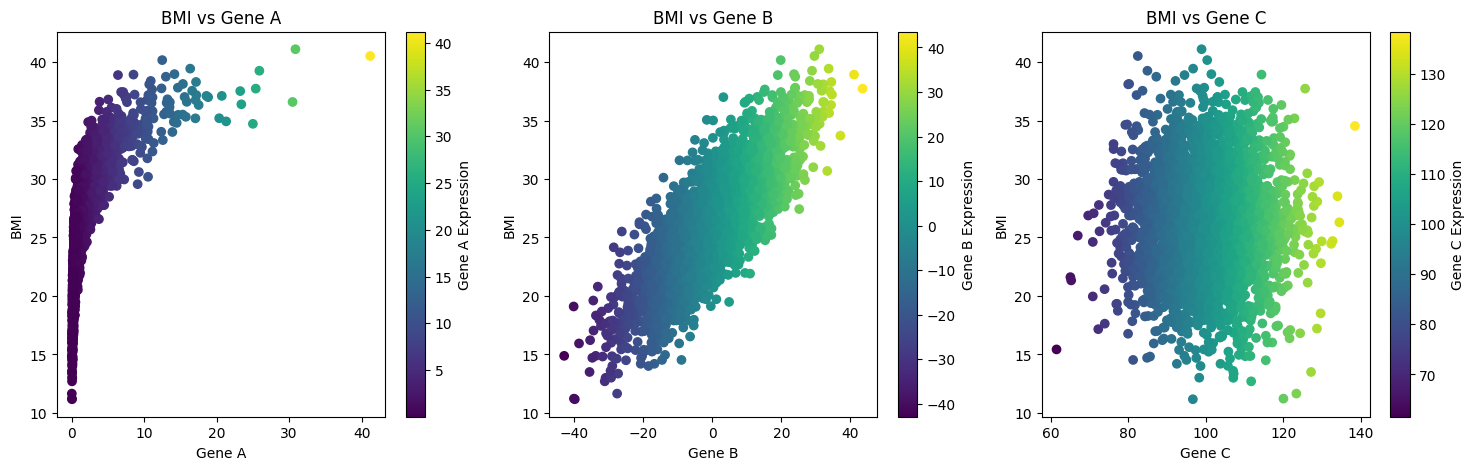

In [41]:
# Scatter plot of BMI vs Gene A, Gene B, and Gene C

# Set up the figure
plt.figure(figsize=(18, 5))

# Plot 1: Gene A
plt.subplot(1, 3, 1)
sc1 = plt.scatter(merged_df_genes['geneA'], merged_df_genes['BMI'], c=merged_df_genes['geneA'], cmap='viridis')
plt.colorbar(sc1, label='Gene A Expression')
plt.xlabel('Gene A')
plt.ylabel('BMI')
plt.title('BMI vs Gene A')

# Plot 2: Gene B
plt.subplot(1, 3, 2)
sc2 = plt.scatter(merged_df_genes['geneB'], merged_df_genes['BMI'], c=merged_df_genes['geneB'], cmap='viridis')
plt.colorbar(sc2, label='Gene B Expression')
plt.xlabel('Gene B')
plt.ylabel('BMI')
plt.title('BMI vs Gene B')

# Plot 3: Gene C
plt.subplot(1, 3, 3)
sc3 = plt.scatter(merged_df_genes['geneC'], merged_df_genes['BMI'], c=merged_df_genes['geneC'], cmap='viridis')
plt.colorbar(sc3, label='Gene C Expression')
plt.xlabel('Gene C')
plt.ylabel('BMI')
plt.title('BMI vs Gene C'); 

**Interpretation**

To explore the relationship between gene expression and BMI, scatterplots were created for Gene A, Gene B, and Gene C, with BMI on the y-axis and gene expression values on the x-axis. Each point was color-coded based on the corresponding gene expression level.

Gene A shows a positive but non-linear relationship with BMI. As Gene A expression increased, BMI also increased, though the trend appears to level off at higher expression levels. 

Gene B displays a strong, linear relationship with BMI. Higher levels of Gene B expression seem to be associated with higher BMI values. The clear upward trend and smooth color gradient suggests that Gene B may be a strong predictor of BMI in this dataset.

Gene C, on the other hand, does not show any clear relationship with BMI. The data points are widely scattered, and no obvious trend is observed. This suggests that Gene C is unlikely to be a possible predictor of BMI.

In summary, Gene B shows the strongest and most consistent relationship with BMI, followed by Gene A with a weaker, non-linear association. Gene C does not appear to be associated with BMI in any meaningful way.

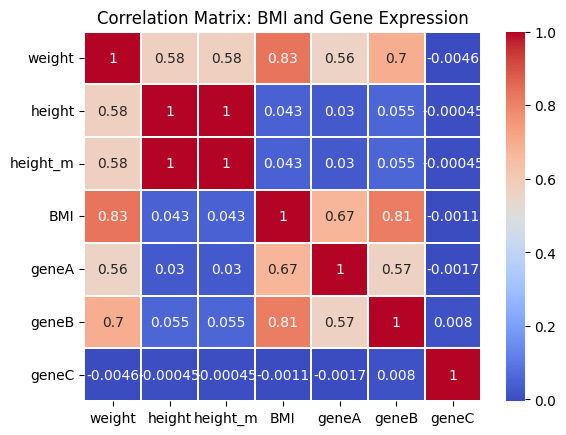

In [42]:
# Heatmap of correlations
sns.heatmap(merged_df_genes.select_dtypes(include=['float64', 'int64']).corr(), annot=True, linewidths=0.05, cmap ='coolwarm')
plt.title('Correlation Matrix: BMI and Gene Expression');

**Interpretation**

The heatmap above shows the Pearson correlation coefficients between body measurements (weight, height, BMI) and various genes (geneA, geneB, geneC). Each value represents how strongly two variables are linearly related, with values ranging from -1 (perfect negative correlation) to +1 (perfect positive correlation).

BMI is strongly positively correlated with geneB (r = 0.81), indicating that individuals with higher geneB expression tend to have higher BMI. There is also a moderately strong positive correlation between BMI and geneA (r = 0.67), suggesting that increased geneA expression is associated with higher BMI, though the relationship is not as strong as with geneB. In contrast, the correlation between BMI and geneC is virtually zero (r = -0.001), implying that geneC expression does not appear to be related to BMI in this dataset.



SOLUTION END